In [ ]:
import torch
import torch.nn as nn
import numpy as np 
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt 

bc = datasets.load_breast_cancer()
x, y = bc.data, bc.target

n_samples, n_features = x.shape
print (n_samples, n_features)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1234)

569 30


In [115]:
#scale data

sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [116]:
x_train=torch.from_numpy(x_train.astype(np.float32))
x_test=torch.from_numpy(x_test.astype(np.float32))
y_train=torch.from_numpy(y_train.astype(np.float32))
y_test=torch.from_numpy(y_test.astype(np.float32))

y_train = y_train.view(y_train.shape[0],1)
y_test = y_test.view(y_test.shape[0],1)

<h1>Model

In [117]:
class LogisticRegression(nn.Module):

    def __init__(self, n_input_features):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(n_input_features, 1)

    def forward(self, x):
        y_pred = torch.sigmoid(self.linear(x))
        return y_pred

In [ ]:
model = LogisticRegression(n_features)

criterion = nn.BCELoss()
learning_rate=0.01
optimizer = torch.optim.SGD(model.parameters(),lr=learning_rate)
num_epochs = 100

for epochs in range(num_epochs):
    y_pred =  model(x_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    if (epochs+1) % 10 == 0 :
        print(f'epoch: {epochs+1} loss = {loss.item():.4f}')

epoch: 10 loss = 0.5724
epoch: 20 loss = 0.4688
epoch: 30 loss = 0.4028
epoch: 40 loss = 0.3575
epoch: 50 loss = 0.3244
epoch: 60 loss = 0.2992
epoch: 70 loss = 0.2792
epoch: 80 loss = 0.2629
epoch: 90 loss = 0.2493
epoch: 100 loss = 0.2377


In [ ]:
with torch.no_grad():
    y_pred = model(x_test)
    y_pred_class = y_pred.round()
    accuracy = y_pred_class.eq(y_test).sum() / float(y_test.shape[0])
    print(f'accuracy = {accuracy:.4f}')

accuracy = 0.9123


<h2> scaling the data visuallized: before and after 

Before scaling:
                         mean         std        min        max
mean radius        14.127292    3.524049    6.98100    28.1100
mean texture       19.289649    4.301036    9.71000    39.2800
mean perimeter     91.969033   24.298981   43.79000   188.5000
mean area         654.889104  351.914129  143.50000  2501.0000
mean smoothness     0.096360    0.014064    0.05263     0.1634
mean compactness    0.104341    0.052813    0.01938     0.3454

After scaling:
                           mean      std       min       max
mean radius      -3.153111e-15  1.00088 -2.029648  3.971288
mean texture     -6.568462e-15  1.00088 -2.229249  4.651889
mean perimeter   -6.993039e-16  1.00088 -1.984504  3.976130
mean area        -8.553985e-16  1.00088 -1.454443  5.250529
mean smoothness   6.081447e-15  1.00088 -3.112085  4.770911
mean compactness -1.136369e-15  1.00088 -1.610136  4.568425


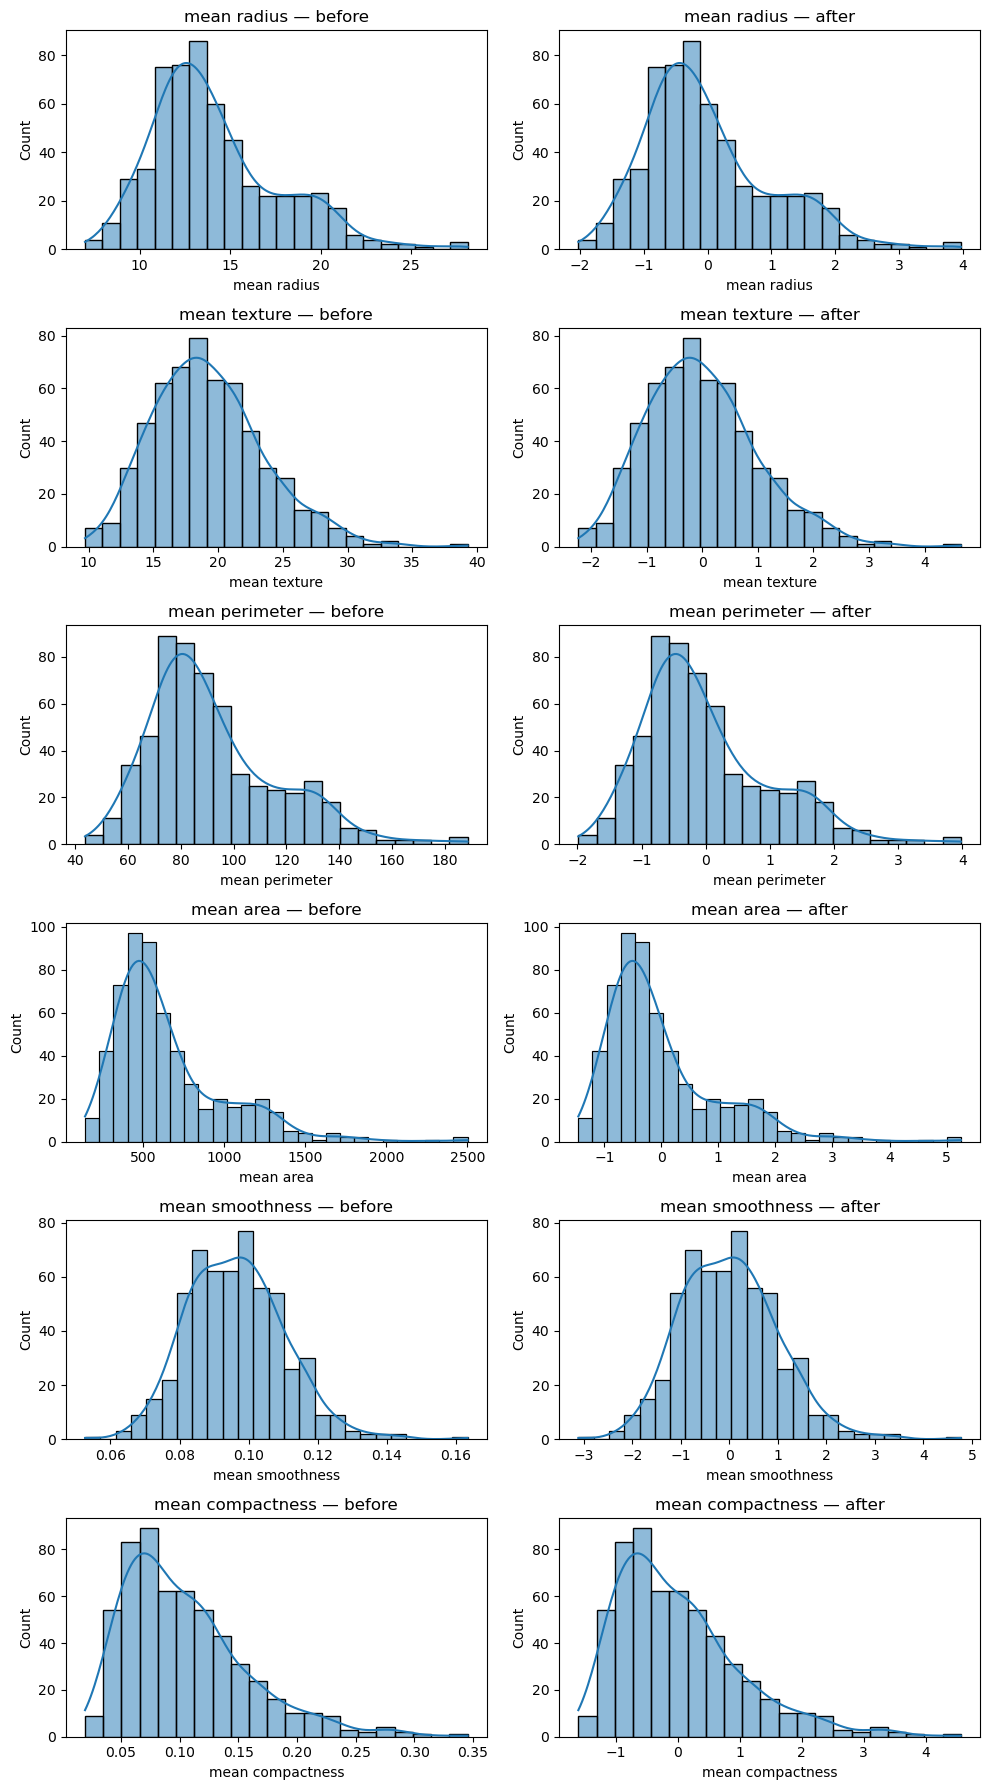

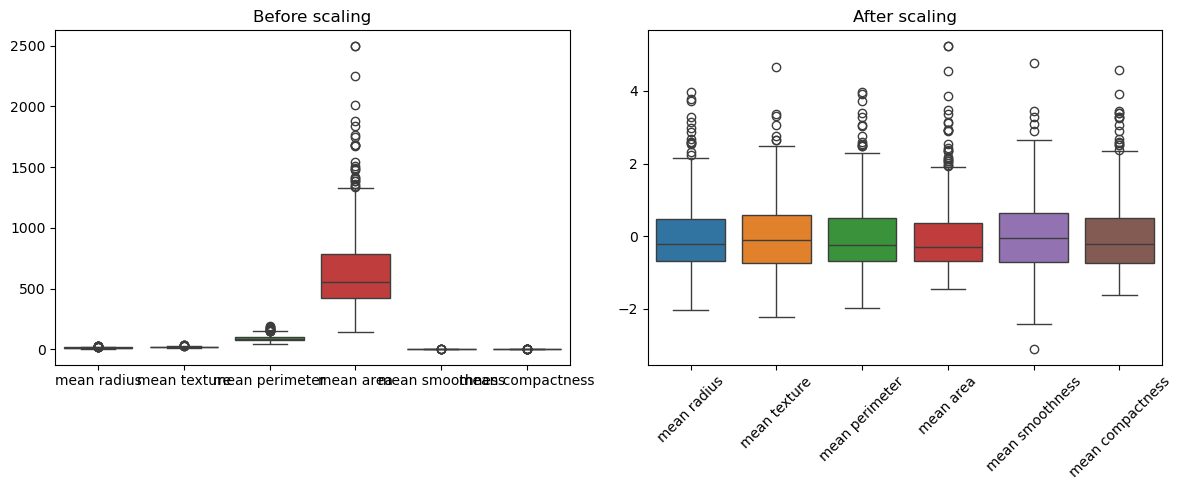

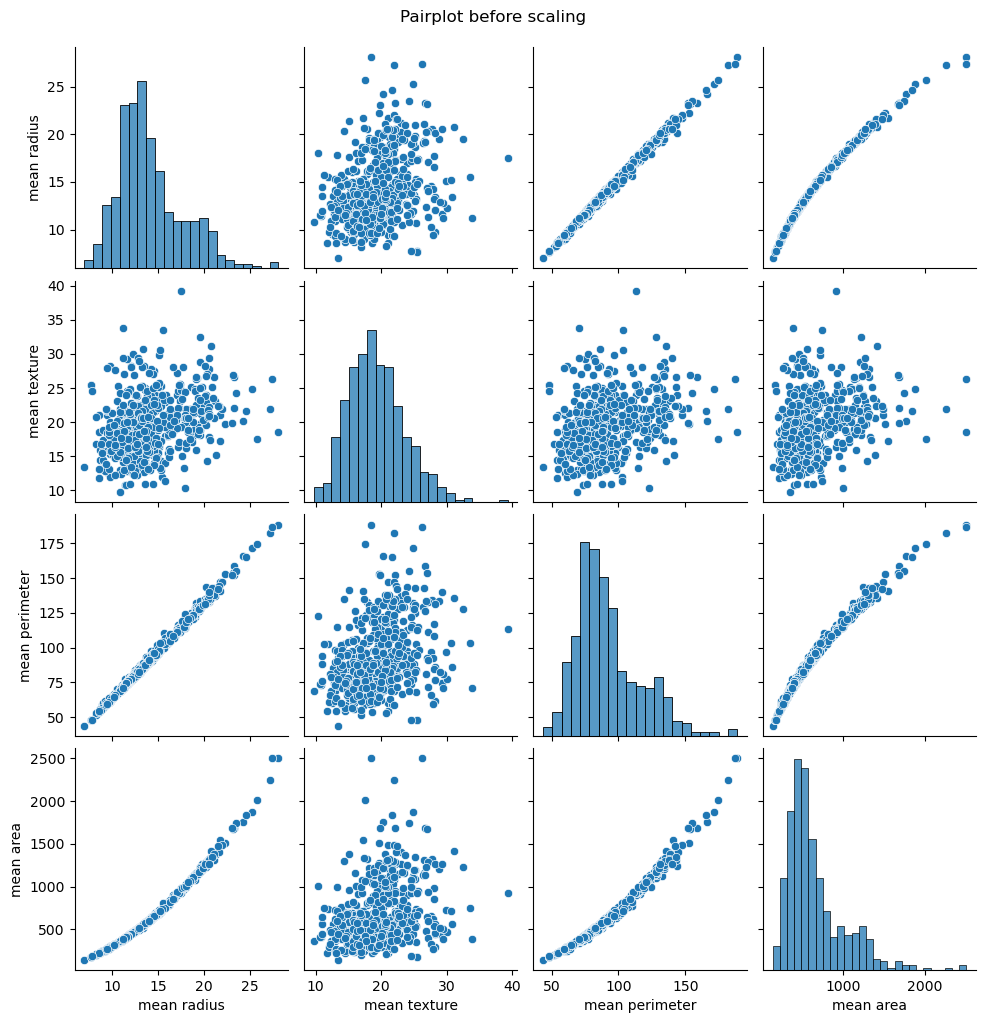

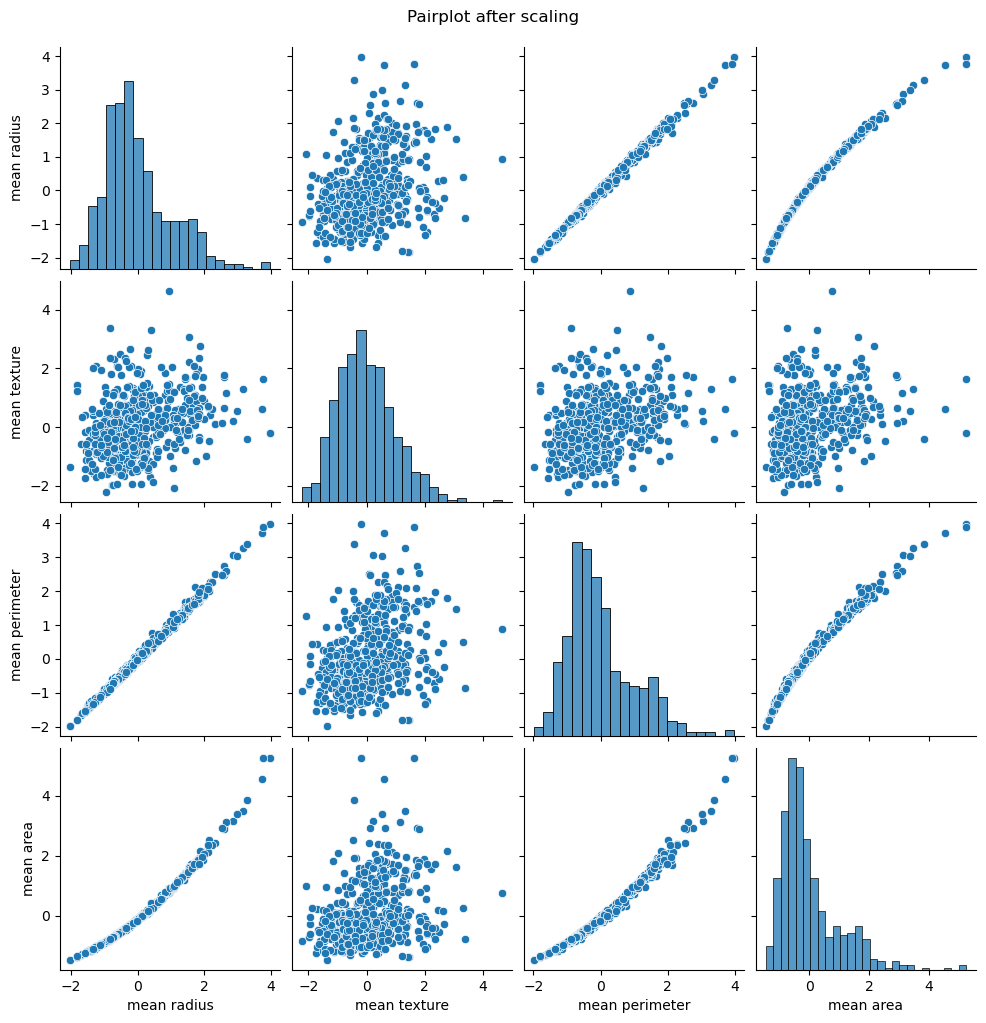

In [ ]:
import pandas as pd
import seaborn as sns

# load data
bc = datasets.load_breast_cancer()
X = pd.DataFrame(bc.data, columns=bc.feature_names)

# take a small subset of features for clearer plots
cols = X.columns[:6]  # change as desired
before = X[cols].copy()

# scale
sc = StandardScaler()
after_arr = sc.fit_transform(X)
after = pd.DataFrame(after_arr, columns=X.columns)[cols]

# Summary statistics
print("Before scaling:\n", before.describe().T[['mean','std','min','max']])
print("\nAfter scaling:\n", after.describe().T[['mean','std','min','max']])

# Histograms (before vs after)
fig, axes = plt.subplots(len(cols), 2, figsize=(10, 3*len(cols)))
for i, c in enumerate(cols):
    sns.histplot(before[c], kde=True, ax=axes[i,0])
    axes[i,0].set_title(f"{c} — before")
    sns.histplot(after[c], kde=True, ax=axes[i,1])
    axes[i,1].set_title(f"{c} — after")
plt.tight_layout()
plt.show()

# Boxplots (compare distributions)
fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.boxplot(data=before, ax=axes[0])
axes[0].set_title("Before scaling")
sns.boxplot(data=after, ax=axes[1])
axes[1].set_title("After scaling")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pairplot for small feature set (optional)
sns.pairplot(before.iloc[:, :4])        # before
plt.suptitle("Pairplot before scaling", y=1.02)
plt.show()
sns.pairplot(after.iloc[:, :4])         # after
plt.suptitle("Pairplot after scaling", y=1.02)
plt.show()